In [25]:
!pip install vaderSentiment wordcloud

In [26]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

In [27]:
df = pd.read_csv("realdonaldtrump.csv")

df.head()

,id,link,content,date,retweets,favorites,mentions,hashtags
0,1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 13:54:25,510,917,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-04 20:00:10,34,267,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 08:38:08,13,19,NaN,NaN
3,1741160716,https://twitter.com/realDonaldTrump/status/174...,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 15:40:15,11,26,NaN,NaN
4,1773561338,https://twitter.com/realDonaldTrump/status/177...,"""My persona will never be that of a wallflower...",2009-05-12 09:07:28,1375,1945,NaN,NaN


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43352 entries, 0 to 43351
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         43352 non-null  int64 
 1   link       43352 non-null  object
 2   content    43352 non-null  object
 3   date       43352 non-null  object
 4   retweets   43352 non-null  int64 
 5   favorites  43352 non-null  int64 
 6   mentions   20386 non-null  object
 7   hashtags   5583 non-null   object
dtypes: int64(3), object(5)
memory usage: 2.6+ MB


In [29]:
df.columns

Index(['id', 'link', 'content', 'date', 'retweets', 'favorites', 'mentions',
       'hashtags'],
      dtype='object')

In [30]:
df = df[["id", "date", "content", "retweets", "favorites", "mentions", "hashtags"]].copy()

df.head()

,id,date,content,retweets,favorites,mentions,hashtags
0,1698308935,2009-05-04 13:54:25,Be sure to tune in and watch Donald Trump on L...,510,917,NaN,NaN
1,1701461182,2009-05-04 20:00:10,Donald Trump will be appearing on The View tom...,34,267,NaN,NaN
2,1737479987,2009-05-08 08:38:08,Donald Trump reads Top Ten Financial Tips on L...,13,19,NaN,NaN
3,1741160716,2009-05-08 15:40:15,New Blog Post: Celebrity Apprentice Finale and...,11,26,NaN,NaN
4,1773561338,2009-05-12 09:07:28,"""My persona will never be that of a wallflower...",1375,1945,NaN,NaN


In [31]:
print("Liczba wierszy:", len(df))
print("Liczba braków w content:", df["content"].isna().sum())
print("Liczba duplikatów content:", df["content"].duplicated().sum())

Liczba wierszy: 43352
Liczba braków w content: 0
Liczba duplikatów content: 261


In [32]:
print("Liczba wierszy przed usunięciem duplikatów:", len(df))

df = df.drop_duplicates(subset=["content"]).copy()

print("Liczba wierszy po usunięciu duplikatów:", len(df))
print("Liczba duplikatów content po czyszczeniu:", df["content"].duplicated().sum())

Liczba wierszy przed usunięciem duplikatów: 43352
Liczba wierszy po usunięciu duplikatów: 43091
Liczba duplikatów content po czyszczeniu: 0


In [33]:
def clean_tweet(text):
    text = str(text)
    text = text.lower()

    # usunięcie linków
    text = re.sub(r"http\S+|www\S+", "", text)

    # usunięcie oznaczeń użytkowników, np. @username
    text = re.sub(r"@\w+", "", text)

    # usunięcie znaku hashtagu, ale zostawienie samego słowa
    text = re.sub(r"#", "", text)

    # podstawowe zamiany encji HTML
    text = re.sub(r"&amp;", "and", text)
    text = re.sub(r"&lt;", "<", text)
    text = re.sub(r"&gt;", ">", text)

    # zostawiamy tylko litery i spacje
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # usunięcie nadmiarowych spacji
    text = re.sub(r"\s+", " ", text).strip()

    return text

def clean_for_vader(text):
    text = str(text)

    # usunięcie linków
    text = re.sub(r"http\S+|www\S+", "", text)

    # usunięcie oznaczeń użytkowników
    text = re.sub(r"@\w+", "", text)

    # zamiana encji HTML
    text = re.sub(r"&amp;", "and", text)
    text = re.sub(r"&lt;", "<", text)
    text = re.sub(r"&gt;", ">", text)

    # usunięcie nadmiarowych spacji
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [34]:
df["vader_text"] = df["content"].apply(clean_for_vader)

In [35]:
df["vader_text"] = df["content"].apply(clean_for_vader)
df["clean_text"] = df["content"].apply(clean_tweet)

df[["content", "vader_text", "clean_text"]].head(10)

,content,vader_text,clean_text
0,Be sure to tune in and watch Donald Trump on L...,Be sure to tune in and watch Donald Trump on L...,be sure to tune in and watch donald trump on l...
1,Donald Trump will be appearing on The View tom...,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...
2,Donald Trump reads Top Ten Financial Tips on L...,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...
3,New Blog Post: Celebrity Apprentice Finale and...,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale and ...
4,"""My persona will never be that of a wallflower...","""My persona will never be that of a wallflower...",my persona will never be that of a wallflower ...
5,"Miss USA Tara Conner will not be fired - ""I've...","Miss USA Tara Conner will not be fired - ""I've...",miss usa tara conner will not be fired i ve al...
6,Listen to an interview with Donald Trump discu...,Listen to an interview with Donald Trump discu...,listen to an interview with donald trump discu...
7,"""Strive for wholeness and keep your sense of w...","""Strive for wholeness and keep your sense of w...",strive for wholeness and keep your sense of wo...
8,"Enter the ""Think Like A Champion"" signed book ...","Enter the ""Think Like A Champion"" signed book ...",enter the think like a champion signed book an...
9,"""When the achiever achieves, it's not a platea...","""When the achiever achieves, it's not a platea...",when the achiever achieves it s not a plateau ...


In [36]:
print("Liczba wierszy przed usunięciem pustych clean_text:", len(df))

empty_clean_text = (df["clean_text"].str.len() == 0).sum()
print("Liczba pustych tekstów po czyszczeniu:", empty_clean_text)

df = df[df["clean_text"].str.len() > 0].copy()

print("Liczba wierszy po usunięciu pustych clean_text:", len(df))

Liczba wierszy przed usunięciem pustych clean_text: 43091
Liczba pustych tekstów po czyszczeniu: 93
Liczba wierszy po usunięciu pustych clean_text: 42998


In [44]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    return analyzer.polarity_scores(text)["compound"]

df["vader_score"] = df["vader_text"].apply(get_vader_score)

df[["vader_text", "vader_score"]].head(100)

,vader_text,vader_score
0,Be sure to tune in and watch Donald Trump on L...,0.5255
1,Donald Trump will be appearing on The View tom...,0.7712
2,Donald Trump reads Top Ten Financial Tips on L...,0.6468
3,New Blog Post: Celebrity Apprentice Finale and...,0.0000
4,"""My persona will never be that of a wallflower...",0.0000
...,...,...
95,We're all very happy to hear of Bret Michael's...,0.9117
96,"Looking forward to the 2010 Miss USA Pageant, ...",-0.1531
97,"Congratulations to our new Miss USA, the beaut...",0.8957
98,Put this on your calendar: The Celebrity Appre...,0.0000


In [46]:
def get_sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["vader_score"].apply(get_sentiment_label)

In [47]:
sentiment_counts = df["sentiment"].value_counts()
sentiment_percentages = df["sentiment"].value_counts(normalize=True) * 100

print("Liczebność klas:")
print(sentiment_counts)

print("\nProcentowy udział klas:")
print(sentiment_percentages.round(2))

Liczebność klas:
sentiment
positive    25038
negative    10660
neutral      7300
Name: count, dtype: int64

Procentowy udział klas:
sentiment
positive    58.23
negative    24.79
neutral     16.98
Name: proportion, dtype: float64


In [39]:
analyzer.polarity_scores("miss")

{'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.1531}

In [40]:
analyzer.polarity_scores("miss universe")

{'neg': 0.615, 'neu': 0.385, 'pos': 0.0, 'compound': -0.1531}

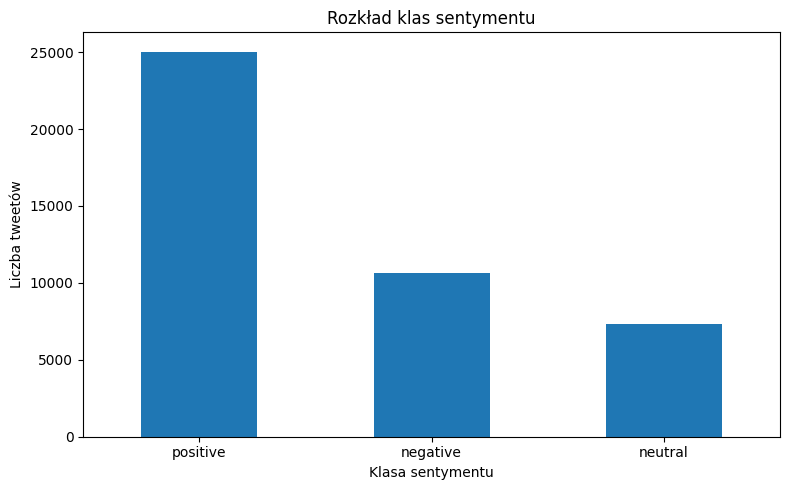

In [48]:
plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.xlabel("Klasa sentymentu")
plt.ylabel("Liczba tweetów")
plt.title("Rozkład klas sentymentu")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

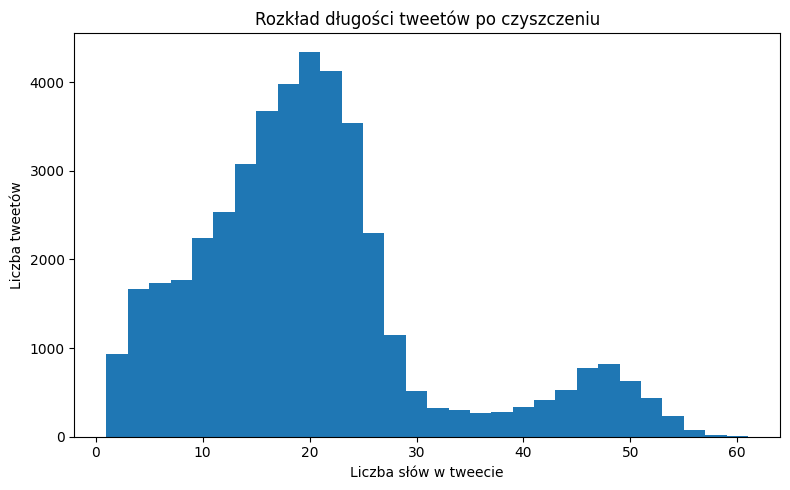

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=30)

plt.xlabel("Liczba słów w tweecie")
plt.ylabel("Liczba tweetów")
plt.title("Rozkład długości tweetów po czyszczeniu")
plt.tight_layout()

plt.savefig("tweet_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
df["word_count"].describe()

,word_count
count,42998.000000
mean,19.766338
std,11.478640
min,1.000000
25%,12.000000
50%,18.000000
75%,24.000000
max,61.000000


In [50]:
stop_words = {
    "the", "and", "to", "of", "a", "in", "for", "is", "on", "it", "that",
    "this", "with", "be", "are", "was", "at", "as", "by", "from", "or",
    "an", "have", "has", "not", "will", "we", "you", "i", "they", "he",
    "she", "his", "her", "our", "their", "my", "your", "me", "but", "so",
    "do", "does", "did", "can", "could", "would", "should", "there",
    "here", "about", "into", "than", "then", "just", "what", "when",
    "where", "who", "why", "how", "all", "out", "up", "down", "over",
    "under", "again", "more", "most", "some", "any", "very"
}

In [52]:
all_words = []

for text in df["clean_text"]:
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]
    all_words.extend(words)

word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

most_common_words

[('realdonaldtrump', 8622),
 ('great', 6692),
 ('trump', 6667),
 ('twitter', 3678),
 ('com', 3520),
 ('thank', 3046),
 ('president', 2981),
 ('pic', 2858),
 ('people', 2713),
 ('thanks', 2335),
 ('now', 2090),
 ('country', 2004),
 ('get', 1968),
 ('new', 1956),
 ('donald', 1875),
 ('america', 1827),
 ('obama', 1778),
 ('time', 1732),
 ('like', 1726),
 ('big', 1710)]

In [53]:
custom_stop_words = {
    "realdonaldtrump",
    "donald",
    "trump",
    "twitter",
    "com",
    "pic",
    "http",
    "https",
    "www",
    "amp",
    "rt"
}

stop_words = stop_words.union(custom_stop_words)

In [54]:
all_words = []

for text in df["clean_text"]:
    words = text.split()
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]
    all_words.extend(words)

word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20)

most_common_words

[('great', 6692),
 ('thank', 3046),
 ('president', 2981),
 ('people', 2713),
 ('thanks', 2335),
 ('now', 2090),
 ('country', 2004),
 ('get', 1968),
 ('new', 1956),
 ('america', 1827),
 ('obama', 1778),
 ('time', 1732),
 ('like', 1726),
 ('big', 1710),
 ('good', 1693),
 ('one', 1631),
 ('don', 1588),
 ('make', 1526),
 ('never', 1489),
 ('many', 1441)]

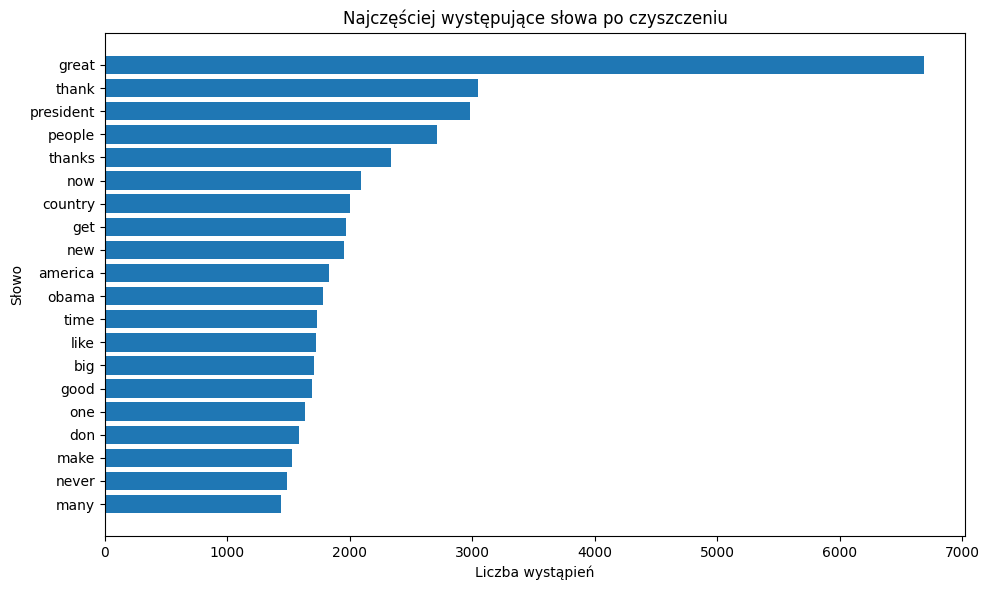

In [55]:
words = [item[0] for item in most_common_words]
counts = [item[1] for item in most_common_words]

plt.figure(figsize=(10, 6))

plt.barh(words, counts)

plt.xlabel("Liczba wystąpień")
plt.ylabel("Słowo")
plt.title("Najczęściej występujące słowa po czyszczeniu")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("most_common_words.png", dpi=300, bbox_inches="tight")
plt.show()

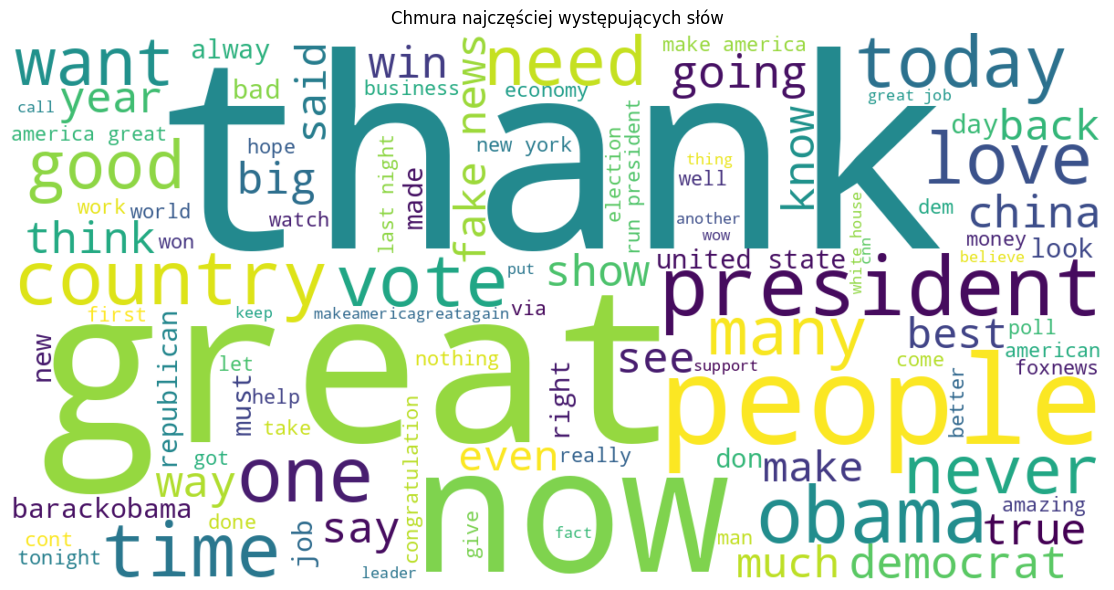

In [56]:
text_for_wordcloud = " ".join(all_words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Chmura najczęściej występujących słów")
plt.tight_layout()

plt.savefig("wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
for label in ["positive", "neutral", "negative"]:
    print("\n" + "=" * 40)
    print(label.upper())
    print("=" * 40)

    examples = df[df["sentiment"] == label][
        ["content", "vader_text", "clean_text", "vader_score", "sentiment"]
    ].head(5)

    display(examples)


POSITIVE


,content,vader_text,clean_text,vader_score,sentiment
0,Be sure to tune in and watch Donald Trump on L...,Be sure to tune in and watch Donald Trump on L...,be sure to tune in and watch donald trump on l...,0.5255,positive
1,Donald Trump will be appearing on The View tom...,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...,0.7712,positive
2,Donald Trump reads Top Ten Financial Tips on L...,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...,0.6468,positive
5,"Miss USA Tara Conner will not be fired - ""I've...","Miss USA Tara Conner will not be fired - ""I've...",miss usa tara conner will not be fired i ve al...,0.4809,positive
6,Listen to an interview with Donald Trump discu...,Listen to an interview with Donald Trump discu...,listen to an interview with donald trump discu...,0.7506,positive



NEUTRAL


,content,vader_text,clean_text,vader_score,sentiment
3,New Blog Post: Celebrity Apprentice Finale and...,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale and ...,0.0,neutral
4,"""My persona will never be that of a wallflower...","""My persona will never be that of a wallflower...",my persona will never be that of a wallflower ...,0.0,neutral
9,"""When the achiever achieves, it's not a platea...","""When the achiever achieves, it's not a platea...",when the achiever achieves it s not a plateau ...,0.0,neutral
12,"""...these days...we could all use a little of ...","""...these days...we could all use a little of ...",these days we could all use a little of the po...,0.0,neutral
15,"""Keep it fast, short and direct - whatever it ...","""Keep it fast, short and direct - whatever it ...",keep it fast short and direct whatever it is d...,0.0,neutral



NEGATIVE


,content,vader_text,clean_text,vader_score,sentiment
26,"RE: FB Vanity URLs: SF Chronicle - ""David Beck...","RE: FB Vanity URLs: SF Chronicle - ""David Beck...",re fb vanity urls sf chronicle david beckham w...,-0.2263,negative
34,Donald Trump backs 'Apprentice' Randal Pinkett...,Donald Trump backs 'Apprentice' Randal Pinkett...,donald trump backs apprentice randal pinkett f...,-0.0516,negative
41,Watch the Miss Universe competition LIVE from ...,Watch the Miss Universe competition LIVE from ...,watch the miss universe competition live from ...,-0.1531,negative
42,Reminder: The Miss Universe competition will b...,Reminder: The Miss Universe competition will b...,reminder the miss universe competition will be...,-0.1531,negative
44,- More hysterical DSRL videos featuring Donald...,- More hysterical DSRL videos featuring Donald...,more hysterical dsrl videos featuring donald t...,-0.1010,negative


In [58]:
example_tweets = (
    df.groupby("sentiment", group_keys=False)
      .apply(lambda x: x[["content", "vader_text", "clean_text", "vader_score", "sentiment"]].head(10))
)

example_tweets.to_csv("sentiment_examples.csv", index=False)

example_tweets

/tmp/ipykernel_3420/1359541915.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[["content", "vader_text", "clean_text", "vader_score", "sentiment"]].head(10))


,content,vader_text,clean_text,vader_score,sentiment
26,"RE: FB Vanity URLs: SF Chronicle - ""David Beck...","RE: FB Vanity URLs: SF Chronicle - ""David Beck...",re fb vanity urls sf chronicle david beckham w...,-0.2263,negative
34,Donald Trump backs 'Apprentice' Randal Pinkett...,Donald Trump backs 'Apprentice' Randal Pinkett...,donald trump backs apprentice randal pinkett f...,-0.0516,negative
41,Watch the Miss Universe competition LIVE from ...,Watch the Miss Universe competition LIVE from ...,watch the miss universe competition live from ...,-0.1531,negative
42,Reminder: The Miss Universe competition will b...,Reminder: The Miss Universe competition will b...,reminder the miss universe competition will be...,-0.1531,negative
44,- More hysterical DSRL videos featuring Donald...,- More hysterical DSRL videos featuring Donald...,more hysterical dsrl videos featuring donald t...,-0.1010,negative
92,"Looking forward to the 2010 Miss USA Pageant, ...","Looking forward to the 2010 Miss USA Pageant, ...",looking forward to the miss usa pageant sunday...,-0.1531,negative
96,"Looking forward to the 2010 Miss USA Pageant, ...","Looking forward to the 2010 Miss USA Pageant, ...",looking forward to the miss usa pageant sunday...,-0.1531,negative
139,The Miss Universe Pageant will be on August 23...,The Miss Universe Pageant will be on August 23...,the miss universe pageant will be on august p ...,-0.1531,negative
140,Performing live on the Miss Universe Pageant f...,Performing live on the Miss Universe Pageant f...,performing live on the miss universe pageant f...,-0.1531,negative
151,It's going to get hotter in Las Vegas tonight!...,It's going to get hotter in Las Vegas tonight!...,it s going to get hotter in las vegas tonight ...,-0.2924,negative


In [59]:
output_columns = [
    "id",
    "date",
    "content",
    "vader_text",
    "clean_text",
    "original_length",
    "clean_length",
    "word_count",
    "retweets",
    "favorites",
    "mentions",
    "hashtags",
    "vader_score",
    "sentiment"
]

df[output_columns].to_csv("trump_tweets_preprocessed.csv", index=False)

print("Zapisano plik trump_tweets_preprocessed.csv")
print("Liczba zapisanych wierszy:", len(df))
print("Liczba zapisanych kolumn:", len(output_columns))

Zapisano plik trump_tweets_preprocessed.csv
Liczba zapisanych wierszy: 42998
Liczba zapisanych kolumn: 14


In [60]:
df_check = pd.read_csv("trump_tweets_preprocessed.csv")

print("Wymiary pliku:", df_check.shape)
print("\nKolumny:")
print(df_check.columns.tolist())

df_check.head()

Wymiary pliku: (42998, 14)

Kolumny:
['id', 'date', 'content', 'vader_text', 'clean_text', 'original_length', 'clean_length', 'word_count', 'retweets', 'favorites', 'mentions', 'hashtags', 'vader_score', 'sentiment']


,id,date,content,vader_text,clean_text,original_length,clean_length,word_count,retweets,favorites,mentions,hashtags,vader_score,sentiment
0,1698308935,2009-05-04 13:54:25,Be sure to tune in and watch Donald Trump on L...,Be sure to tune in and watch Donald Trump on L...,be sure to tune in and watch donald trump on l...,117,116,23,510,917,NaN,NaN,0.5255,positive
1,1701461182,2009-05-04 20:00:10,Donald Trump will be appearing on The View tom...,Donald Trump will be appearing on The View tom...,donald trump will be appearing on the view tom...,131,130,22,34,267,NaN,NaN,0.7712,positive
2,1737479987,2009-05-08 08:38:08,Donald Trump reads Top Ten Financial Tips on L...,Donald Trump reads Top Ten Financial Tips on L...,donald trump reads top ten financial tips on l...,116,86,15,13,19,NaN,NaN,0.6468,positive
3,1741160716,2009-05-08 15:40:15,New Blog Post: Celebrity Apprentice Finale and...,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale and ...,103,75,12,11,26,NaN,NaN,0.0000,neutral
4,1773561338,2009-05-12 09:07:28,"""My persona will never be that of a wallflower...","""My persona will never be that of a wallflower...",my persona will never be that of a wallflower ...,109,102,21,1375,1945,NaN,NaN,0.0000,neutral
